In [1]:
import torch
import torch.nn as nn

import math
import matplotlib.pyplot as plt

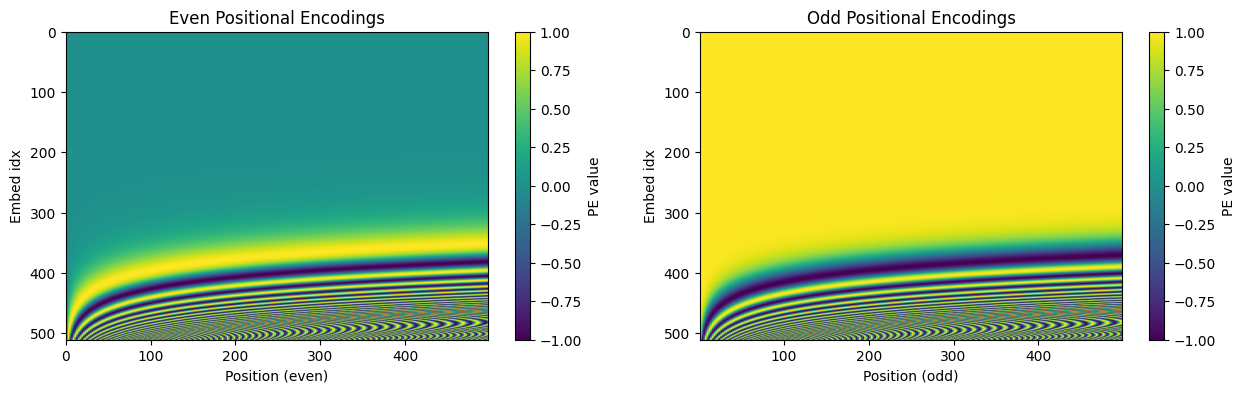

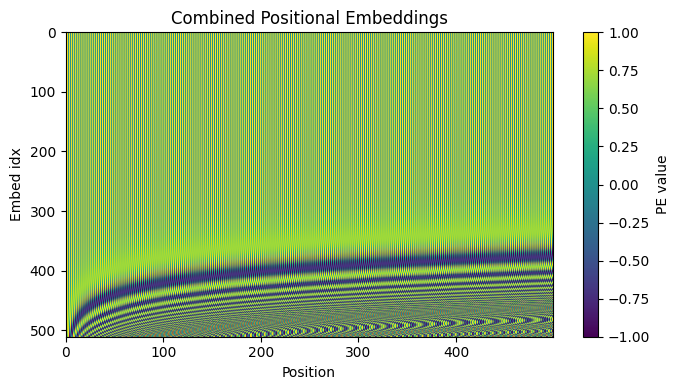

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 9.0930e-01,  9.3641e-01,  9.5814e-01,  ...,  2.2279e-08,
          2.1492e-08,  2.0733e-08],
        [-7.5680e-01, -6.5717e-01, -5.4861e-01,  ...,  4.4559e-08,
          4.2984e-08,  4.1465e-08],
        ...,
        [-6.9610e-01, -8.3007e-01,  8.5732e-01,  ...,  5.5030e-06,
          5.3086e-06,  5.1210e-06],
        [-3.6314e-01,  8.1346e-01,  2.4779e-01,  ...,  5.5253e-06,
          5.3301e-06,  5.1417e-06],
        [ 9.9834e-01,  2.5919e-01, -9.9920e-01,  ...,  5.5476e-06,
          5.3515e-06,  5.1624e-06]])


In [2]:
text_len = 500
emb_size = 512

#generating even numbers
even = torch.arange(0, text_len, 2)
odd = torch.arange(1, text_len, 2)
emb_pos = torch.arange(0, emb_size)
import matplotlib.pyplot as plt

pe_even = torch.sin(even[:, None] / ((10000 ** (2 * emb_pos / emb_size))[None, :]))
pe_odd = torch.cos(odd[:, None] / ((10000 ** (2 * emb_pos / emb_size))[None, :]))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
im0 = axes[0].imshow(pe_even.T, aspect='auto', cmap='viridis', extent=[even[0].item(), even[-1].item(), 0, pe_even.shape[1]-1])
axes[0].set_title('Even Positional Encodings')
axes[0].set_xlabel('Position (even)')
axes[0].set_ylabel('Embed idx')
axes[0].invert_yaxis()
plt.colorbar(im0, ax=axes[0], label='PE value')

im1 = axes[1].imshow(pe_odd.T, aspect='auto', cmap='viridis', extent=[odd[0].item(), odd[-1].item(), 0, pe_odd.shape[1]-1])
axes[1].set_title('Odd Positional Encodings')
axes[1].set_xlabel('Position (odd)')
axes[1].set_ylabel('Embed idx')
axes[1].invert_yaxis()
plt.colorbar(im1, ax=axes[1], label='PE value')

# Combine even and odd into one positional embedding matrix
out = torch.empty(text_len, emb_size)
out[0::2] = pe_even
out[1::2] = pe_odd

# Plot the combined positional embeddings as a new subplot
fig_comb, ax_comb = plt.subplots(1, 1, figsize=(7, 4))
im_comb = ax_comb.imshow(out.T, aspect='auto', cmap='viridis', extent=[0, text_len-1, 0, emb_size-1])
ax_comb.set_title('Combined Positional Embeddings')
ax_comb.set_xlabel('Position')
ax_comb.set_ylabel('Embed idx')
ax_comb.invert_yaxis()
plt.colorbar(im_comb, ax=ax_comb, label='PE value')
plt.tight_layout()
plt.show()




print(pe_even)

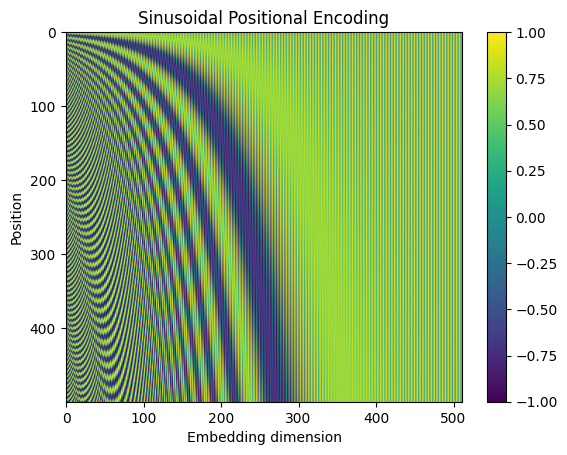

In [3]:
# Parameters (as in the paper)
max_len = 500
d_model = 512

# Create positional encodings
pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len).unsqueeze(1)
div_term = torch.exp(
    torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
)

pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

# Visualize
plt.imshow(pe, aspect='auto')
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.colorbar()
plt.title("Sinusoidal Positional Encoding")
plt.show()


In [4]:
import torch.nn.functional as F
a = torch.tensor([[2, 3, 2],
                  [0, 1, 3]], dtype=torch.long)
print(a.shape)
F.one_hot(a).shape

torch.Size([2, 3])


torch.Size([2, 3, 4])

In [5]:
#checking self-attention dimensions

batch_dim = 4
n_tokens = 8
emb_dim = 64
attn_dim = 16

Wq = nn.Linear(emb_dim, attn_dim)
Wk = nn.Linear(emb_dim, attn_dim)
Wv = nn.Linear(emb_dim, attn_dim)

input = torch.rand([batch_dim, n_tokens, emb_dim]) * 5
print(f"input shape: {input.shape}, dtype: {input.dtype}")

Q = Wq(input)
print(f"q shape: {Q.shape}, dtype: {Q.dtype}")
K = Wk(input)
print(f"k shape: {K.shape}, dtype: {K.dtype}")
V = Wv(input)
print(f"v shape: {V.shape}, dtype: {V.dtype}")

attn_score = torch.matmul(Q, K.transpose(-2, -1))
print(f"attn_score shape (before scaling): {attn_score.shape}, dtype: {attn_score.dtype}")
attn_score /= attn_dim ** 0.5 
print(f"attn_score dtype (after scaling): {attn_score.dtype}")

attn_score = torch.softmax(attn_score, dim=-1)
print(f"attn_score shape (after softmax): {attn_score.shape}, dtype: {attn_score.dtype}")
#print("attn_score values\n", attn_score)

v_sums = torch.matmul(attn_score, V)
print(f"sum shape, {v_sums.shape}")

input shape: torch.Size([4, 8, 64]), dtype: torch.float32
q shape: torch.Size([4, 8, 16]), dtype: torch.float32
k shape: torch.Size([4, 8, 16]), dtype: torch.float32
v shape: torch.Size([4, 8, 16]), dtype: torch.float32
attn_score shape (before scaling): torch.Size([4, 8, 8]), dtype: torch.float32
attn_score dtype (after scaling): torch.float32
attn_score shape (after softmax): torch.Size([4, 8, 8]), dtype: torch.float32
sum shape, torch.Size([4, 8, 16])


In [6]:
a = torch.arange(0, 27, dtype=torch.float).view((3, 3, 3))

mask = torch.triu(torch.ones(3, 3, dtype=torch.bool), diagonal=1)
masked_scores = a.masked_fill(mask, float('-inf'))
masked_scores

tensor([[[ 0., -inf, -inf],
         [ 3.,  4., -inf],
         [ 6.,  7.,  8.]],

        [[ 9., -inf, -inf],
         [12., 13., -inf],
         [15., 16., 17.]],

        [[18., -inf, -inf],
         [21., 22., -inf],
         [24., 25., 26.]]])

How to get indices of sequences that contain the EOS tokens?

In [9]:
import torch

# 2D tensor of token ids (5 rows, 4 columns)
tensor = torch.tensor([
    [10, 20, 30, 3],   # row 0 — last token is 3 ✓
    [11, 21, 31, 5],   # row 1 — last token is 5
    [12, 22, 32, 3],   # row 2 — last token is 3 ✓
    [13, 23, 33, 7],   # row 3 — last token is 7
    [14, 24, 34, 3],   # row 4 — last token is 3 ✓
])

print(len(tensor))

target_id = 3

# Step by step
print("Original tensor:")
print(tensor)
print()

# Step 1: Compare last column to target
mask = tensor[:, -1] == target_id
print(f"Boolean mask (last token == {target_id}):")
print(mask)  # [True, False, True, False, True]
print()

# Step 2: Get indices where mask is True
indices = mask.nonzero(as_tuple=True)[0]
print(f"Row indices where last token is {target_id}:")
print(indices)  # [0, 2, 4]
print()

# Step 3: Use indices to select those rows
selected_rows = tensor[indices]
print("Selected rows:")
print(selected_rows)
print()

# --- Bonus: compare nonzero with and without as_tuple ---
print("--- nonzero comparison ---")
print(f"Without as_tuple: {mask.nonzero()}")        # 2D tensor (N x 1)
print(f"With as_tuple:    {mask.nonzero(as_tuple=True)}")  # tuple of 1D tensors

5
Original tensor:
tensor([[10, 20, 30,  3],
        [11, 21, 31,  5],
        [12, 22, 32,  3],
        [13, 23, 33,  7],
        [14, 24, 34,  3]])

Boolean mask (last token == 3):
tensor([ True, False,  True, False,  True])

Row indices where last token is 3:
tensor([0, 2, 4])

Selected rows:
tensor([[10, 20, 30,  3],
        [12, 22, 32,  3],
        [14, 24, 34,  3]])

--- nonzero comparison ---
Without as_tuple: tensor([[0],
        [2],
        [4]])
With as_tuple:    (tensor([0, 2, 4]),)


In [ ]:

tensor = torch.tensor([
    [10], [20], [30], [3],   # row 0 — last token is 3 ✓
])

target_id = 3

# Step by step
print("Original tensor:")
print(tensor)
print()

# Step 1: Compare last column to target
mask = tensor == target_id
print(f"Boolean mask (last token == {target_id}):")
print(mask.shape)  # [True, False, True, False, True]
print()

Original tensor:
tensor([[10],
        [20],
        [30],
        [ 3]])

Boolean mask (last token == 3):
torch.Size([4, 1])



4